# Gradient Descent and Linear Regression for Traffic Forecasting

This notebook walks through two linear models for microservice traffic:
1. **Model 1**: Predict **CPU** from time (window index) — used to forecast CPU in the near future.
2. **Model 2**: Predict **latency** from CPU and network (RX/TX) — used to estimate latency given forecasted CPU.

We use the Microservices Bottleneck Detection dataset (processed CSVs with per-window metrics).

---
## 1. Introduction to Gradient Descent and Linear Regression

**Linear regression** fits a linear function to data by minimizing the mean squared error (MSE). Given features $X$ and target $y$:

$$\hat{y} = X\theta \quad \text{, minimize} \quad \frac{1}{n}\sum_i (y_i - \hat{y}_i)^2$$

- **Closed-form (normal equation)**: $\theta = (X^T X)^{-1} X^T y$ — one-step solution (with small ridge for stability).
- **Gradient descent**: start with $\theta = 0$, then repeatedly update $\theta \leftarrow \theta - \alpha \cdot \frac{2}{n} X^T(X\theta - y)$. The step size $\alpha$ is the **learning rate**; we run for a fixed number of **epochs** (or until the gradient is tiny).

Both methods minimize the same MSE; gradient descent converges to the same solution if we tune learning rate and epochs. If GD predictions look wrong, it's usually because they haven't converged yet.

---
## 2. The Two Models We Will Implement

| Model | Features ($X$) | Target ($y$) | Purpose |
|-------|----------------|--------------|--------|
| **Model 1** | Intercept, time (window index) | CPU | Forecast CPU in 30 minutes using a simple linear trend. |
| **Model 2** | Intercept, CPU, net RX, net TX | Latency (ms) | Estimate latency from current (or forecasted) CPU and network. Fit only on **baseline** (pre-saturation) data. |

**End-to-end**: Use Model 1 to forecast CPU (and optionally net RX/TX) 30 minutes ahead, then plug those into Model 2 to estimate latency at that time.

---
## 3. Dataset

We use the **processed** microservices dataset: one CSV per (service, scenario, graph). Each row is a request; metrics (CPU, memory, network RX/TX) are constant per **window_id**. We aggregate by window to get one row per time window with mean latency and the shared metrics. Scenarios prefixed with `<c-latency>-` in the `scenarios/` folder are chosen for clear latency saturation. Expect: CPU and network rising over time, with latency staying low then jumping when the system saturates.

### Setup: install dependencies

Run the cell below **once** if you get `ModuleNotFoundError: No module named 'numpy'` (or pandas/matplotlib). It installs packages into whichever Python the notebook kernel is using. Then re-run the next cell. Prefer using a venv: create one with `python -m venv .venv`, install with `pip install -r requirements.txt`, then choose that interpreter as the kernel.

In [2]:
# Install dependencies into the current Jupyter kernel (run this cell once if you get ModuleNotFoundError).
# If you use a venv, select it as the kernel: Kernel → Change Kernel → Python (./.venv/...)
%pip install numpy pandas matplotlib ipywidgets --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Add project root so we can import from visualise_processed_dataset and linear_regression_saturation
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "linear_regression_saturation.py").exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Helpers from our scripts
from visualise_processed_dataset import (
    find_metric_columns,
    aggregate_by_window,
    plot_time_series,
)
from linear_regression_saturation import (
    load_scenario_data,
    iter_candidate_scenarios,
    baseline_end_index,
    fit_closed_form,
    fit_gradient_descent,
    scenario_duration_minutes,
    SCENARIOS_DIR,
    CANDIDATE_PREFIX,
    SERVICES,
)

# Paths (edit DATA_DIR if your processed dataset is elsewhere)
DATA_DIR = ROOT / "processed_dataset"
if not DATA_DIR.exists():
    DATA_DIR = Path("/Users/opeyemionikute/Downloads/archive/processed_dataset")

# Pick first <c-latency> scenario for the rest of the notebook
candidate_pngs = sorted(p for p in SCENARIOS_DIR.glob("*.png") if p.name.startswith(CANDIDATE_PREFIX))
if not candidate_pngs:
    raise FileNotFoundError(f"No files matching {CANDIDATE_PREFIX}* in {SCENARIOS_DIR}")
CHOSEN_STEM = candidate_pngs[0].stem[len(CANDIDATE_PREFIX):]
print(f"Chosen scenario: {CHOSEN_STEM}")

# Load aggregated data for this scenario
win = load_scenario_data(DATA_DIR, CHOSEN_STEM)
if win is None:
    raise FileNotFoundError(f"Could not load scenario {CHOSEN_STEM} from {DATA_DIR}")
metric_cols = find_metric_columns(win)
metric_cols = {k: [c for c in v if c in win.columns] for k, v in metric_cols.items()}
print(f"Windows: {len(win)}")

Chosen scenario: cpu_aug9_25min_400_8_graph_1
Windows: 290


---
## 4. Plot Metrics (CPU, Network, Latency) for the Chosen Scenario

Time series of CPU, memory, network RX/TX, and latency per window — the same view as `visualise_processed_dataset.py`.

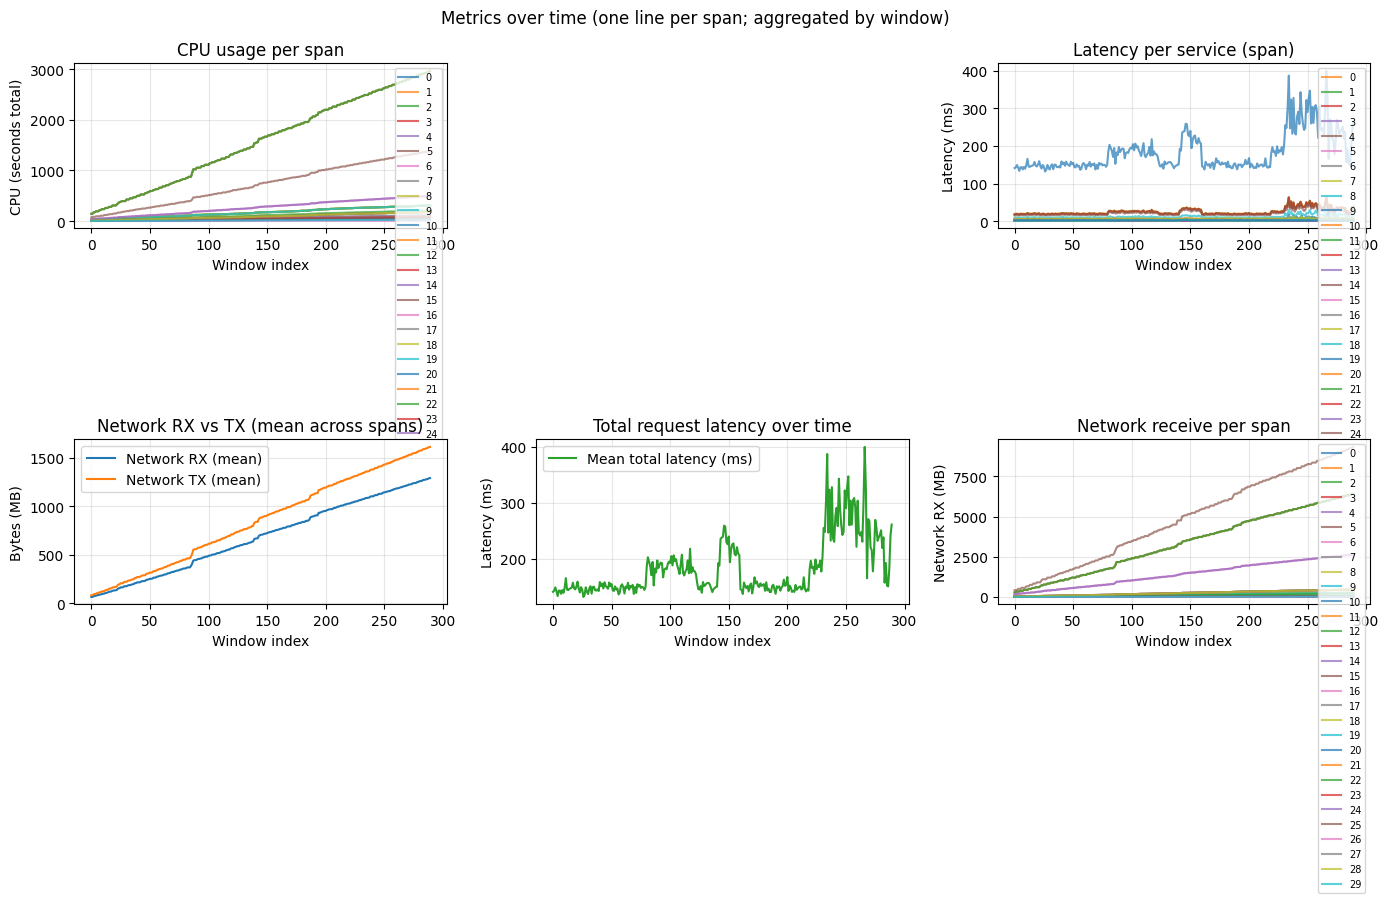

In [4]:
plot_time_series(win, metric_cols, show=True)

---
## 5. Model 1: Predicting CPU from Time (Closed-Form and Gradient Descent)

We predict **CPU** using only time (window index): $X = [1, t]$, $y = \text{CPU}$. Both closed-form and gradient descent minimize the same MSE; gradient descent needs a suitable learning rate and enough epochs to converge.

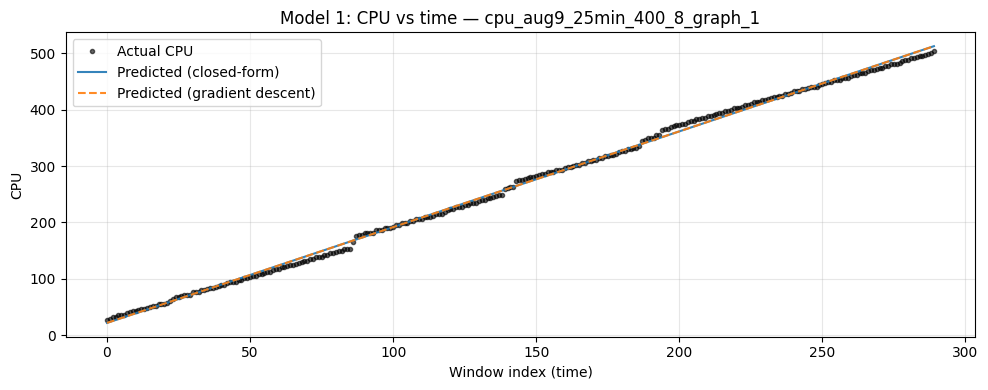

In [4]:
# Build X = [1, t], y = CPU (mean across spans per window)
cpu_mean = win[metric_cols["cpu"]].mean(axis=1).values
n_windows = len(cpu_mean)
t = np.arange(n_windows, dtype=float)
X_cpu = np.column_stack([np.ones(n_windows), t])
y_cpu = cpu_mean

# Closed-form
theta_cf_cpu = fit_closed_form(X_cpu, y_cpu)
pred_cf_cpu = X_cpu @ theta_cf_cpu

# Gradient descent (scaled features for stability)
X_cpu_gd = X_cpu.copy()
X_cpu_gd[:, 1] = (X_cpu_gd[:, 1] - X_cpu_gd[:, 1].mean()) / (X_cpu_gd[:, 1].std() + 1e-8)
y_cpu_gd = (y_cpu - y_cpu.mean()) / (y_cpu.std() + 1e-8)
theta_gd_cpu = fit_gradient_descent(X_cpu_gd, y_cpu_gd, lr=0.5, epochs=5000)
pred_gd_cpu_raw = X_cpu_gd @ theta_gd_cpu
pred_gd_cpu = pred_gd_cpu_raw * y_cpu.std() + y_cpu.mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, y_cpu, "k.", alpha=0.6, label="Actual CPU")
ax.plot(t, pred_cf_cpu, "C0-", alpha=0.9, label="Predicted (closed-form)")
ax.plot(t, pred_gd_cpu, "C1--", alpha=0.9, label="Predicted (gradient descent)")
ax.set_xlabel("Window index (time)")
ax.set_ylabel("CPU")
ax.set_title(f"Model 1: CPU vs time — {CHOSEN_STEM}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.1 Interactive: Tune Learning Rate and Epochs

Use the sliders to see how gradient descent fails to converge when the learning rate is too small or epochs too few, and converges when they are adequate.

In [5]:
from ipywidgets import interact, FloatLogSlider, IntSlider

def run_gd_cpu(lr=0.1, epochs=5000):
    X_gd = X_cpu.copy()
    X_gd[:, 1] = (X_gd[:, 1] - X_gd[:, 1].mean()) / (X_gd[:, 1].std() + 1e-8)
    y_gd = (y_cpu - y_cpu.mean()) / (y_cpu.std() + 1e-8)
    theta = fit_gradient_descent(X_gd, y_gd, lr=lr, epochs=epochs)
    pred = (X_gd @ theta) * y_cpu.std() + y_cpu.mean()
    mse = np.mean((y_cpu - pred) ** 2)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t, y_cpu, "k.", alpha=0.6, label="Actual CPU")
    ax.plot(t, pred_cf_cpu, "C0-", alpha=0.8, label="Closed-form")
    ax.plot(t, pred, "C1--", alpha=0.9, label=f"GD (lr={lr}, epochs={epochs}), MSE={mse:.4f}")
    ax.set_xlabel("Window index")
    ax.set_ylabel("CPU")
    ax.set_title("Model 1: effect of learning rate and epochs")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(
    run_gd_cpu,
    lr=FloatLogSlider(value=0.1, base=10, min=-3, max=0, step=0.2, description="Learning rate"),
    epochs=IntSlider(value=5000, min=100, max=50000, step=500, description="Epochs"),
)

interactive(children=(FloatLogSlider(value=0.1, description='Learning rate', max=0.0, min=-3.0, step=0.2), Int…

<function __main__.run_gd_cpu(lr=0.1, epochs=5000)>

---
## 6. Traffic Forecasting Problem

We want to estimate **how future demand will impact latency**: if load (and thus CPU and network) keeps trending up, what latency can we expect in 30 minutes? We do this in two steps:
1. **Forecast CPU (and optionally net RX/TX)** in 30 minutes using Model 1–style linear extrapolation.
2. **Plug those values into Model 2** (latency from CPU and network) to estimate latency at that time.

Model 2 is only reliable in the **baseline** (pre-saturation) regime; once the system saturates, latency is no longer linear in CPU/network.

---
## 7. Model 2: Predicting Latency from CPU and Network

Features: intercept, CPU, network RX (MB), network TX (MB). Target: latency (ms). We fit on **baseline only** (windows before the latency spike) so the linear assumption holds.

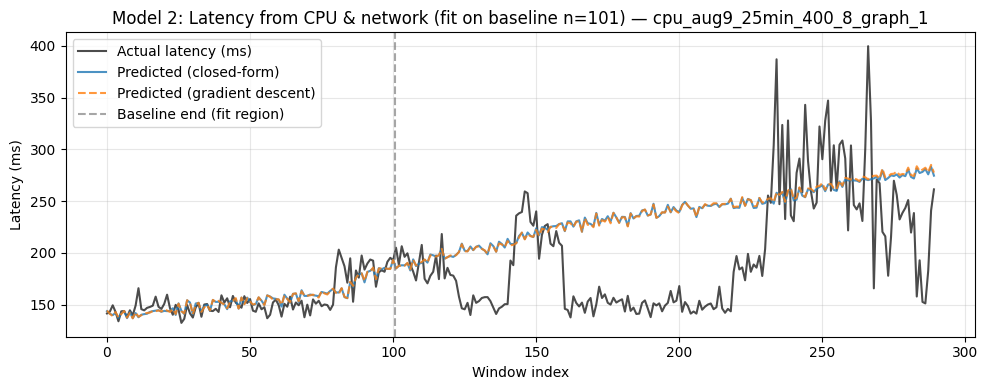

In [6]:
# Build X = [1, cpu, net_rx, net_tx], y = latency (ms)
net_rx = win[metric_cols["network_rx"]].mean(axis=1).values / 1e6
net_tx = win[metric_cols["network_tx"]].mean(axis=1).values / 1e6
lat_ms = (win["_total_latency"] / 1e3).values

X_lat = np.column_stack([np.ones(n_windows), cpu_mean, net_rx, net_tx])
y_lat = lat_ms

# Baseline: only use windows before saturation
baseline_end = baseline_end_index(y_lat, percentile=75)
X_fit = X_lat[:baseline_end]
y_fit = y_lat[:baseline_end]

# Scale for gradient descent
X_gd_fit = X_fit.copy()
X_gd_fit[:, 1:] = (X_gd_fit[:, 1:] - X_gd_fit[:, 1:].mean(axis=0)) / (X_gd_fit[:, 1:].std(axis=0) + 1e-8)
y_mean_lat, y_std_lat = y_fit.mean(), y_fit.std() + 1e-8
y_gd_fit = (y_fit - y_mean_lat) / y_std_lat

theta_cf_lat = fit_closed_form(X_fit, y_fit)
theta_gd_lat = fit_gradient_descent(X_gd_fit, y_gd_fit, lr=0.1, epochs=50_000)

# Predict on full timeline (model was fit on baseline only)
X_gd_full = X_lat.copy()
X_gd_full[:, 1:] = (X_gd_full[:, 1:] - X_fit[:, 1:].mean(axis=0)) / (X_fit[:, 1:].std(axis=0) + 1e-8)
pred_cf_lat = X_lat @ theta_cf_lat
pred_gd_lat = (X_gd_full @ theta_gd_lat) * y_std_lat + y_mean_lat

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(n_windows), y_lat, "k-", alpha=0.7, label="Actual latency (ms)")
ax.plot(np.arange(n_windows), pred_cf_lat, "C0-", alpha=0.8, label="Predicted (closed-form)")
ax.plot(np.arange(n_windows), pred_gd_lat, "C1--", alpha=0.8, label="Predicted (gradient descent)")
ax.axvline(baseline_end - 0.5, color="gray", linestyle="--", alpha=0.7, label="Baseline end (fit region)")
ax.set_xlabel("Window index")
ax.set_ylabel("Latency (ms)")
ax.set_title(f"Model 2: Latency from CPU & network (fit on baseline n={baseline_end}) — {CHOSEN_STEM}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Why Only the Baseline?

Once saturation hits, latency **stops being linear** in CPU and network: it flattens or jumps. Fitting a single linear model over the full timeline would be pulled by those high-latency points and would mispredict both the normal and saturated regions. By fitting **only on baseline** (pre-spike) data, we get a model that describes "latency as a function of load" in the regime where that relationship is roughly linear. We can then use it to estimate latency for **forecasted** CPU/network (e.g. 30 minutes ahead) as long as we stay in a range the model was trained on.

---
## 9. End-to-End: Forecast CPU in 30 Minutes, Then Latency

1. Use the **Model 1** trend (CPU vs time) on the baseline segment to extrapolate CPU (and optionally net RX/TX) to a time 30 minutes after the end of the baseline.
2. Build the feature vector for that future point and pass it to **Model 2** to get predicted latency.

Forecast at t = 449 (~30 min after baseline end):
  CPU = 746.6775,  net_rx = 1895.88 MB,  net_tx = 2371.37 MB
  Predicted latency (closed-form) = 318.4 ms
  Predicted latency (gradient descent) = 318.3 ms


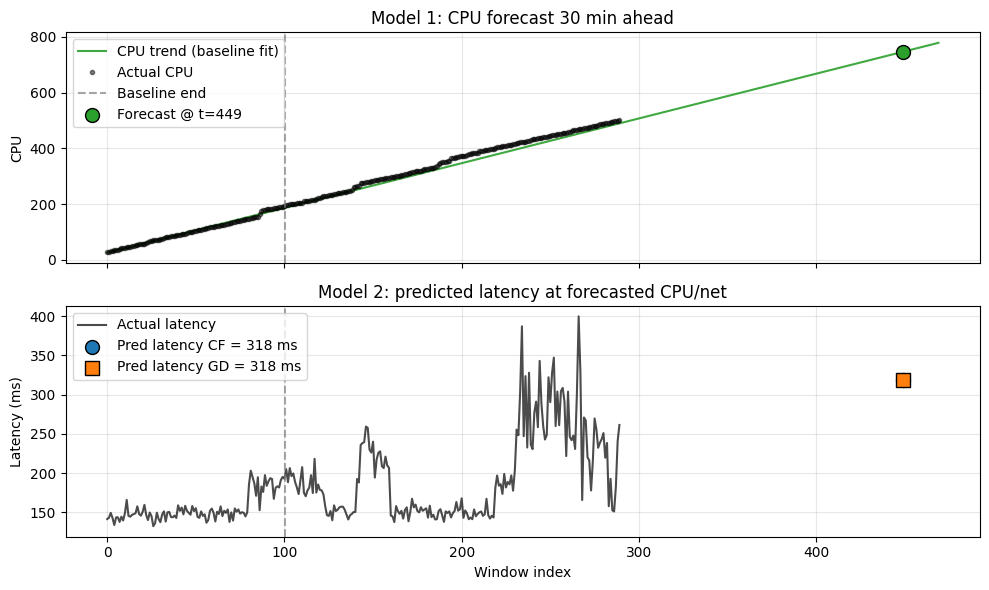

In [7]:
MINUTES_AHEAD = 30
duration_min = scenario_duration_minutes(CHOSEN_STEM)
n_baseline = baseline_end
if duration_min and n_windows > 0:
    windows_per_min = n_windows / duration_min
    n_windows_ahead = int(round(MINUTES_AHEAD * windows_per_min))
else:
    n_windows_ahead = MINUTES_AHEAD

t_baseline = np.arange(n_baseline, dtype=float)
cpu_b = cpu_mean[:n_baseline]
rx_b = net_rx[:n_baseline]
tx_b = net_tx[:n_baseline]

# Linear extrapolation of CPU, net_rx, net_tx to t_future
t_future = n_baseline + n_windows_ahead
poly_cpu = np.polyfit(t_baseline, cpu_b, 1)
poly_rx = np.polyfit(t_baseline, rx_b, 1)
poly_tx = np.polyfit(t_baseline, tx_b, 1)

cpu_30 = np.polyval(poly_cpu, t_future)
rx_30 = np.polyval(poly_rx, t_future)
tx_30 = np.polyval(poly_tx, t_future)

# Model 2: predict latency at that (cpu, rx, tx)
X_30 = np.array([[1.0, cpu_30, rx_30, tx_30]])
lat_30_cf = (X_30 @ theta_cf_lat).item()
X_30_gd = X_30.copy()
X_30_gd[:, 1:] = (X_30[:, 1:] - X_fit[:, 1:].mean(axis=0)) / (X_fit[:, 1:].std(axis=0) + 1e-8)
lat_30_gd = (X_30_gd @ theta_gd_lat).item() * y_std_lat + y_mean_lat

print(f"Forecast at t = {t_future:.0f} (~{MINUTES_AHEAD} min after baseline end):")
print(f"  CPU = {cpu_30:.4f},  net_rx = {rx_30:.2f} MB,  net_tx = {tx_30:.2f} MB")
print(f"  Predicted latency (closed-form) = {lat_30_cf:.1f} ms")
print(f"  Predicted latency (gradient descent) = {lat_30_gd:.1f} ms")

# Optional: plot CPU trend and the forecast point
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
t_plot = np.linspace(0, t_future + 20, 200)
ax1.plot(t_plot, np.polyval(poly_cpu, t_plot), "C2-", alpha=0.9, label="CPU trend (baseline fit)")
ax1.plot(np.arange(n_windows), cpu_mean, "k.", alpha=0.5, label="Actual CPU")
ax1.axvline(n_baseline - 0.5, color="gray", linestyle="--", alpha=0.7, label="Baseline end")
ax1.scatter([t_future], [cpu_30], color="C2", s=100, zorder=5, edgecolors="black", label=f"Forecast @ t={t_future:.0f}")
ax1.set_ylabel("CPU")
ax1.set_title("Model 1: CPU forecast 30 min ahead")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

ax2.plot(np.arange(n_windows), y_lat, "k-", alpha=0.7, label="Actual latency")
ax2.axvline(n_baseline - 0.5, color="gray", linestyle="--", alpha=0.7)
ax2.scatter([t_future], [lat_30_cf], color="C0", s=100, zorder=5, marker="o", edgecolors="black", label=f"Pred latency CF = {lat_30_cf:.0f} ms")
ax2.scatter([t_future], [lat_30_gd], color="C1", s=100, zorder=5, marker="s", edgecolors="black", label=f"Pred latency GD = {lat_30_gd:.0f} ms")
ax2.set_xlabel("Window index")
ax2.set_ylabel("Latency (ms)")
ax2.set_title("Model 2: predicted latency at forecasted CPU/net")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()